# Imports necessários

In [94]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path

# Configurações

In [95]:
# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Caminhos do projeto
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cs-training.csv"

# Configurações do Pandas
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Configurações dos gráficos
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# Ignorar warnings desnecessários
warnings.filterwarnings("ignore")

# Obtendo dados

In [96]:
df = pd.read_csv(DATA_PATH, sep=',')

rename_columns = {
    "Unnamed: 0": "id",
    "SeriousDlqin2yrs": "inadimplente",
    "RevolvingUtilizationOfUnsecuredLines": "utilizacao_credito_rotativo",
    "age": "idade",
    "NumberOfTime30-59DaysPastDueNotWorse": "num_atrasos_30_59_dias",
    "DebtRatio": "indice_endividamento",
    "MonthlyIncome": "renda_mensal",
    "NumberOfOpenCreditLinesAndLoans": "num_linhas_credito",
    "NumberOfTimes90DaysLate": "num_atrasos_acima_90_dias",
    "NumberRealEstateLoansOrLines": "num_emprestimos_imobiliarios",
    "NumberOfTime60-89DaysPastDueNotWorse": "num_atrasos_60_89_dias",
    "NumberOfDependents": "num_dependentes",
}

df = df.rename(columns=rename_columns)

In [97]:
target = "inadimplente"
variaveis = [c for c in df.columns if c not in ["id", target]]

# Entendo a base

In [98]:
print("=" * 70)
print("1. DISTRIBUIÇÃO DAS VARIÁVEIS")
print("=" * 70)
print(df[variaveis].describe().T)

1. DISTRIBUIÇÃO DAS VARIÁVEIS
                                 count    mean      std  min     25%     50%     75%        max
utilizacao_credito_rotativo  150000.00    6.05   249.76 0.00    0.03    0.15    0.56   50708.00
idade                        150000.00   52.30    14.77 0.00   41.00   52.00   63.00     109.00
num_atrasos_30_59_dias       150000.00    0.42     4.19 0.00    0.00    0.00    0.00      98.00
indice_endividamento         150000.00  353.01  2037.82 0.00    0.18    0.37    0.87  329664.00
renda_mensal                 120269.00 6670.22 14384.67 0.00 3400.00 5400.00 8249.00 3008750.00
num_linhas_credito           150000.00    8.45     5.15 0.00    5.00    8.00   11.00      58.00
num_atrasos_acima_90_dias    150000.00    0.27     4.17 0.00    0.00    0.00    0.00      98.00
num_emprestimos_imobiliarios 150000.00    1.02     1.13 0.00    0.00    1.00    2.00      54.00
num_atrasos_60_89_dias       150000.00    0.24     4.16 0.00    0.00    0.00    0.00      98.00
num_depend

### Primeiras Impressões:

* eu esperava que *utilizacao_credito_rotativo* seria um valor no intervalo [0, 1] por se tratar da razão uso/limite, mas claramente há valores extremos!!
    * investigar o que são esse valore extremos e se há alguma relação aparente com o target

* *idade* possui um único valor que é erro, cuja idade é 0. podemos descartar sem preocupação

* *indice_endividamento* é a razão passivo/total, então quanto maior esse índice, mais arriscado um cliente (está endividado)

* *num_linhas_credito* e *num_emprestimos_imobiliarios* possuem valores muito altos, como 54 e 58. seriam flags?
    * investigar o que são esse valore extremos e se há alguma relação aparente com o target

* os atrasos claramente possuem flags (96 e 98). quantos são esses registros? carregam informação do target?

* *num_dependentes* faz sentido ter valores altos como 20??


## utilizacao_credito_rotativo

In [ ]:
anomalia_credito_rotativo = (df['utilizacao_credito_rotativo'] > 1)

print(f"\nutilizacao_credito_rotativo > 1: "
      f"{anomalia_credito_rotativo.sum()} registros "
      f"({anomalia_credito_rotativo.mean():.2%})")


utilizacao_credito_rotativo > 1: 3321 registros (2.21%)


In [ ]:
print("\nDistribuição do target (inadimplente) para registros com e sem anomalia de crédito rotativo:\n")
print("\n--- Geral ---")
print(df[target].value_counts(normalize=True))
print("\n--- Com anomalia ---")
print(df[anomalia_credito_rotativo][target].value_counts(normalize=True))
print("\n--- Sem anomalia ---")
print(df[~anomalia_credito_rotativo][target].value_counts(normalize=True))


Distribuição do target (inadimplente) para registros com e sem anomalia de crédito rotativo:


--- Geral ---
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

--- Com anomalia ---
inadimplente
0   0.63
1   0.37
Name: proportion, dtype: float64

--- Sem anomalia ---
inadimplente
0   0.94
1   0.06
Name: proportion, dtype: float64


In [ ]:
df.groupby(target).agg({'utilizacao_credito_rotativo': 'median'})

,utilizacao_credito_rotativo
inadimplente,
0,0.13
1,0.84


#### anomalia do credito rotativo claramente carrega informação sobre o target!!!

## indice_endividamento

In [ ]:
# cerca de 1/4 da base possui anomalia de endividamento (índice de endividamento > 1)

anomalia_endividamento = (df['indice_endividamento'] > 1)

anomalia_endividamento.value_counts(normalize=True)

indice_endividamento
False   0.77
True    0.23
Name: proportion, dtype: float64

In [162]:
# mantém a mesma proporção de inadimplentes para registros com e sem anomalia de endividamento
print("\n--- Com anomalia ---", df[anomalia_endividamento].shape[0], 'registros')
print(df[anomalia_endividamento][target].value_counts(normalize=True))
print("\n--- Sem anomalia ---", df[~anomalia_endividamento].shape[0], 'registros')
print(df[~anomalia_endividamento][target].value_counts(normalize=True))



--- Com anomalia --- 35137 registros
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

--- Sem anomalia --- 114863 registros
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64


In [ ]:
df.groupby(target).agg({'indice_endividamento': 'median'})

,indice_endividamento
inadimplente,
0,0.36
1,0.43


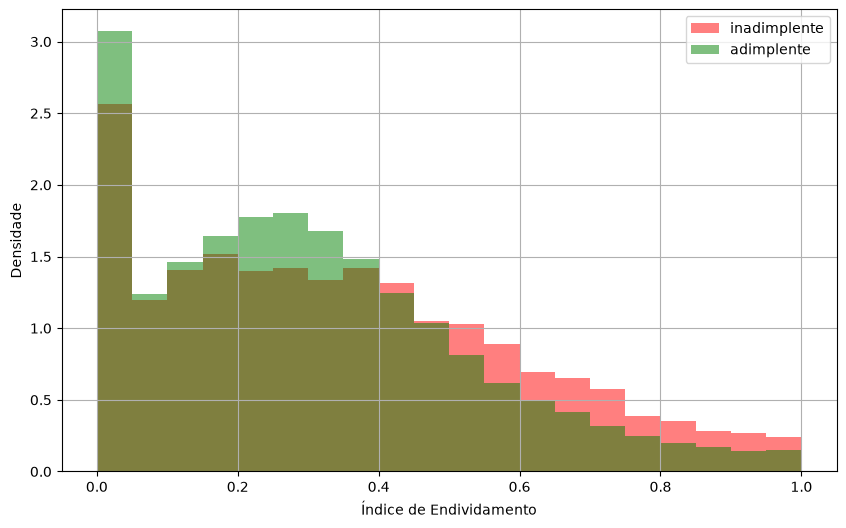

In [110]:
bins = np.arange(
    0,
    1.05,
    0.05
)

df_anom = df[~anomalia_endividamento]

df_anom[df_anom[target] == 1]['indice_endividamento'].hist(
    bins=bins,
    density=True,
    color='red',
    alpha=0.5,
    label='inadimplente'
)

df_anom[df_anom[target] == 0]['indice_endividamento'].hist(
    bins=bins,
    density=True,
    color='green',
    alpha=0.5,
    label='adimplente'
)

plt.legend()
plt.xlabel('Índice de Endividamento')
plt.ylabel('Densidade')
plt.show()

#### talvez cruzar essa info com outra feature possa revelar algo sobre o target

## num_linhas_credito

In [ ]:
df.groupby(target).agg({'num_linhas_credito': 'median'})

,num_linhas_credito
inadimplente,
0,8.00
1,7.00


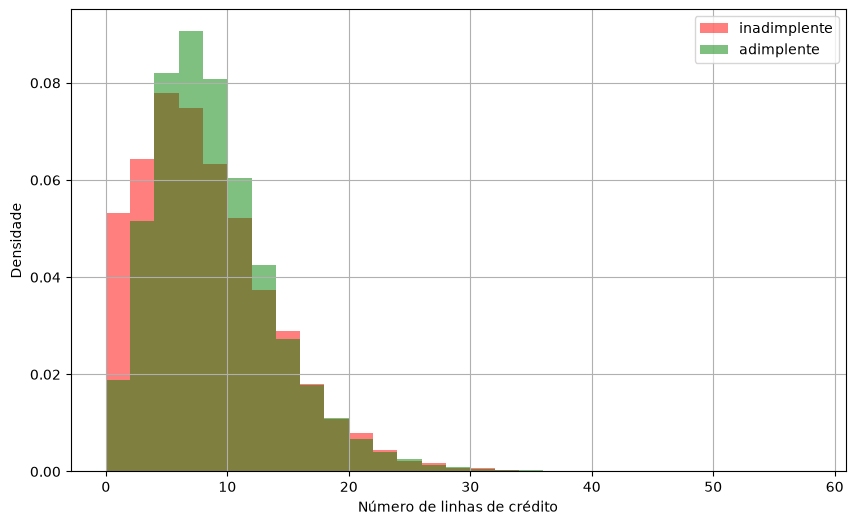

In [ ]:
bins = np.arange(
    df['num_linhas_credito'].min(),
    df['num_linhas_credito'].max() + 1,
    2
)

df[df[target] == 1]['num_linhas_credito'].hist(
    bins=bins,
    density=True,
    color='red',
    alpha=0.5,
    label='inadimplente'
)

df[df[target] == 0]['num_linhas_credito'].hist(
    bins=bins,
    density=True,
    color='green',
    alpha=0.5,
    label='adimplente'
)

plt.legend()
plt.xlabel('Número de linhas de crédito')
plt.ylabel('Densidade')
plt.show()

#### talvez cruzar essa info com outra feature possa revelar algo sobre o target

* a princípio, ter menos linhas de crédito tornam um cliente mais arriscado, mas talvez a renda possa influenciar
    * poucas linhas de crédito mas uma alta renda pode tornar o cliente menos arriscado
    * poucas linhas de crédito mas com alta renda pode tornar o cliente mais arriscado

    

## num_emprestimos_imobiliarios

In [161]:
# a partir de uma certa quantidade de empréstimos imobiliários, a proporção de inadimplentes aumenta significativamente
# podemos ir variando o limite de empréstimos imobiliários para encontrar um ponto de corte que indique anomalia
# a partir de df['num_emprestimos_imobiliarios'] > 4 já observamos um desbalanceamento significativo na proporção de inadimplentes

anomalia_imob = (df['num_emprestimos_imobiliarios'] > 4)

print("\nDistribuição do target (inadimplente) para registros com mais de 4 empréstimos imobiliários:\n")
print('total de', anomalia_imob.sum(), 'registros\n')
print(df[anomalia_imob][target].value_counts(normalize=True))


Distribuição do target (inadimplente) para registros com mais de 4 empréstimos imobiliários:

total de 1482 registros

inadimplente
0   0.85
1   0.15
Name: proportion, dtype: float64


In [127]:
df.groupby(target).agg({'num_emprestimos_imobiliarios': 'median'})

,num_emprestimos_imobiliarios
inadimplente,
0,1.00
1,1.00


## atrasos

In [144]:
colunas_atraso = [
    "num_atrasos_30_59_dias",
    "num_atrasos_60_89_dias",
    "num_atrasos_acima_90_dias",
]
print("Valores mais frequentes nas colunas de atraso (checar códigos especiais):")
for col in colunas_atraso:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index(ascending=False).head(5))

Valores mais frequentes nas colunas de atraso (checar códigos especiais):

--- num_atrasos_30_59_dias ---
num_atrasos_30_59_dias
98    264
96      5
13      1
12      2
11      1
Name: count, dtype: int64

--- num_atrasos_60_89_dias ---
num_atrasos_60_89_dias
98    264
96      5
11      1
9       1
8       2
Name: count, dtype: int64

--- num_atrasos_acima_90_dias ---
num_atrasos_acima_90_dias
98    264
96      5
17      1
15      2
14      2
Name: count, dtype: int64


### claramente 98 e 96 são flags, mas flags de quê?? são coincidentes?

In [ ]:
df[df['num_atrasos_30_59_dias'] == 96][['num_atrasos_30_59_dias', 'num_atrasos_60_89_dias', 'num_atrasos_acima_90_dias']].describe().T

,count,mean,std,min,25%,50%,75%,max
num_atrasos_30_59_dias,5.00,96.00,0.00,96.00,96.00,96.00,96.00,96.00
num_atrasos_60_89_dias,5.00,96.00,0.00,96.00,96.00,96.00,96.00,96.00
num_atrasos_acima_90_dias,5.00,96.00,0.00,96.00,96.00,96.00,96.00,96.00


In [ ]:
df[df['num_atrasos_30_59_dias'] == 98][['num_atrasos_30_59_dias', 'num_atrasos_60_89_dias', 'num_atrasos_acima_90_dias']].describe().T

,count,mean,std,min,25%,50%,75%,max
num_atrasos_30_59_dias,264.00,98.00,0.00,98.00,98.00,98.00,98.00,98.00
num_atrasos_60_89_dias,264.00,98.00,0.00,98.00,98.00,98.00,98.00,98.00
num_atrasos_acima_90_dias,264.00,98.00,0.00,98.00,98.00,98.00,98.00,98.00


### sim, são coincidentes --> menos trabalho :)

In [147]:
atrasos_flag = df['num_atrasos_30_59_dias'].isin([96, 98]) # (como são coincidentes, tanto faz qual coluna usar)

df[atrasos_flag][target].value_counts(normalize=True)

# carrega bastante informação sobre o target!!! cerca de metade desses registros são inadimplentes, enquanto na base geral a proporção é de apenas 7,5%

inadimplente
1   0.55
0   0.45
Name: proportion, dtype: float64

In [ ]:
df[~atrasos_flag][target].value_counts(normalize=True) # sem a flag, a proporção de inadimplentes é igual a da base


inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

## num_dependentes

In [ ]:
df['num_dependentes'].value_counts()
# a partir de 6 dependentes, quase não observamos registros. se dividirmos a base em dois grupos (até 5 dependentes e mais de 5 dependentes), como se comporta a taxa de inadimplência?

num_dependentes
0.00     86902
1.00     26316
2.00     19522
3.00      9483
4.00      2862
5.00       746
6.00       158
7.00        51
8.00        24
10.00        5
9.00         5
20.00        1
13.00        1
Name: count, dtype: int64

In [ ]:
ate_5_dependentes = (df['num_dependentes'] <= 5)
mais_5_dependentes = (df['num_dependentes'] > 5)

print("\nDistribuição do target (inadimplente) para registros com até 5 dependentes e mais de 5 dependentes:\n")
print("\n--- Até 5 dependentes ---", df[ate_5_dependentes].shape[0], 'registros')
print(df[ate_5_dependentes][target].value_counts(normalize=True))
print("\n--- Mais de 5 dependentes ---", df[mais_5_dependentes].shape[0], 'registros')
print(df[mais_5_dependentes][target].value_counts(normalize=True))

# SEMPRE TOMAR CUIDADO COM A QUANTIDADE DE REGISTROS EM CADA GRUPO, POIS PODE HAVER DESBALANCEAMENTO E ISSO PODE LEVAR A CONCLUSÕES ERRADAS. NO CASO ACIMA, O GRUPO COM MAIS DE 5 DEPENDENTES POSSUI APENAS 0,3% DOS REGISTROS, LOGO A TAXA DE INADIMPLÊNCIA DESSE GRUPO NÃO É REPRESENTATIVA.


Distribuição do target (inadimplente) para registros com até 5 dependentes e mais de 5 dependentes:


--- Até 5 dependentes --- 145831 registros
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

--- Mais de 5 dependentes --- 245 registros
inadimplente
0   0.87
1   0.13
Name: proportion, dtype: float64


### essa é uma das features que possui Nans... será que carregam informação?

In [ ]:
dependentes_nans = df['num_dependentes'].isna()

print("Distribuição do target para registros com valores ausentes em 'num_dependentes':")
print('total de', dependentes_nans.sum(), 'registros\n')
print(df[dependentes_nans][target].value_counts(normalize=True))

# proporçao de inadimplentes para registros com valores ausentes em 'num_dependentes' é de 7,5%, ou seja, igual à proporção da base geral. portanto, não há indício de que a ausência de informação sobre o número de dependentes esteja relacionada à inadimplência.


Distribuição do target para registros com valores ausentes em 'num_dependentes':
total de 3924 registros

inadimplente
0   0.95
1   0.05
Name: proportion, dtype: float64


## renda_mensal

In [167]:
df['renda_mensal'].describe()

# é uma feature muito variada. além disso, pode ser que valores puros nao informem nada, afinal, um cliente alta renda nem sempre é um cliente de baixo risco. talvez seja interessante criar uma nova feature a partir da renda.

count    120269.00
mean       6670.22
std       14384.67
min           0.00
25%        3400.00
50%        5400.00
75%        8249.00
max     3008750.00
Name: renda_mensal, dtype: float64

In [196]:
df.groupby(target).agg({'renda_mensal': 'median'})
# inadimplentes tem renda mediana de 4.500, enquanto adimplentes tem renda mediana de 5.500. portanto, não há indício de que a renda esteja relacionada à inadimplência.

,renda_mensal
inadimplente,
0,5466.00
1,4500.00


In [ ]:
for corte in [1000, 2000, 3000, 4000, 5000, 7000, 10000]:
    print('proporção de target para cada faixa de renda abaixo de', corte)
    print('quantidade de registros:', df[df['renda_mensal'] <= corte].shape[0])
    print(df[df['renda_mensal'] <= corte][target].value_counts(normalize=True))

# quase não há diferença na proporção de inadimplentes para diferentes faixas de renda. portanto, não é um claro indicador de inadimplência.
# apesar que essa diferença é cerca de 10000 registros... talvez seja significativo sim, como avaliar??

proporção de target para cada faixa de renda abaixo de 1000
quantidade de registros: 4795
inadimplente
0   0.95
1   0.05
Name: proportion, dtype: float64
proporção de target para cada faixa de renda abaixo de 2000
quantidade de registros: 12003
inadimplente
0   0.92
1   0.08
Name: proportion, dtype: float64
proporção de target para cada faixa de renda abaixo de 3000
quantidade de registros: 25084
inadimplente
0   0.91
1   0.09
Name: proportion, dtype: float64
proporção de target para cada faixa de renda abaixo de 4000
quantidade de registros: 40398
inadimplente
0   0.91
1   0.09
Name: proportion, dtype: float64
proporção de target para cada faixa de renda abaixo de 5000
quantidade de registros: 55859
inadimplente
0   0.91
1   0.09
Name: proportion, dtype: float64
proporção de target para cada faixa de renda abaixo de 7000
quantidade de registros: 79794
inadimplente
0   0.92
1   0.08
Name: proportion, dtype: float64
proporção de target para cada faixa de renda abaixo de 10000
quantidade

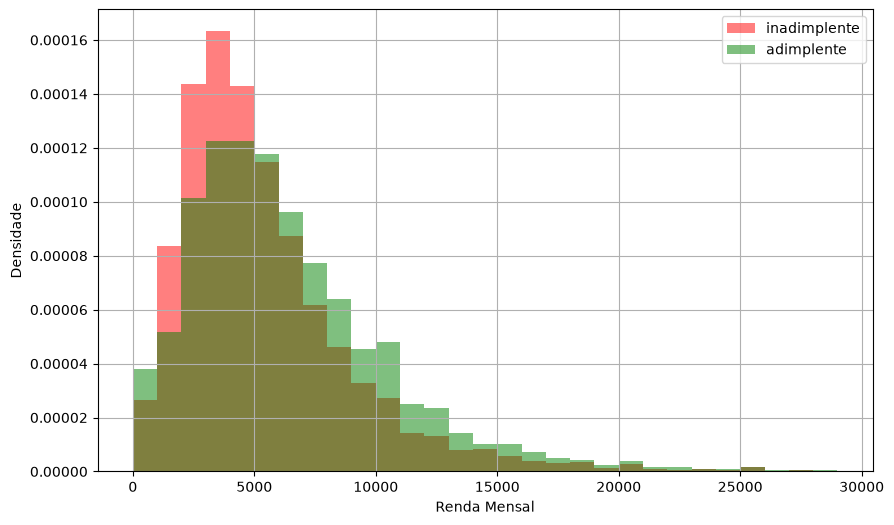

In [200]:
bins = np.arange(
    0,
    3e4,
    1e3
)

df[df[target] == 1]['renda_mensal'].hist(
    bins=bins,
    density=True,
    color='red',
    alpha=0.5,
    label='inadimplente'
)

df[df[target] == 0]['renda_mensal'].hist(
    bins=bins,
    density=True,
    color='green',
    alpha=0.5,
    label='adimplente'
)

plt.legend()
plt.xlabel('Renda Mensal')
plt.ylabel('Densidade')
plt.show()

### renda_mensal é uma das features que possui Nans... vamos verificar se há informação sobre o target

In [ ]:
renda_nan = df['renda_mensal'].isna()

print('quantidade de registros com renda ausente:', renda_nan.sum())
print(df[renda_nan][target].value_counts(normalize=True))

# a proporção de inadimplentes para registros com valores ausentes em 'renda_mensal' é próxima à proporção da base geral.
# ausência dessa informação não parece estar relacionada à inadimplência.
# mas novamente, é 1%... talvez seja significativo sim, como avaliar??

quantidade de registros com renda ausente: 29731
inadimplente
0   0.94
1   0.06
Name: proportion, dtype: float64


## Avaliando porcentagem de targets por quantil das variáveis

In [204]:
print("\n" + "=" * 70)
print("3. TAXA DE INADIMPLÊNCIA POR FAIXA (QUARTIL) DE CADA VARIÁVEL")
print("=" * 70)

quantil = 4

for col in variaveis:
    print(f"\n--- {col} ---")
    try:
        faixas = pd.qcut(df[col], q=quantil, duplicates="drop")
        tabela = df.groupby(faixas, observed=True)[target].agg(
            taxa_inadimplencia="mean", qtd_clientes="count"
        )
        print(tabela)
    except ValueError as e:
        tabela = df.groupby(col, observed=True)[target].agg(
            taxa_inadimplencia="mean", qtd_clientes="count"
        )
        print(f"(não foi possível dividir em quartis: {e})")
        print("Agrupando por valor único da coluna em vez disso:")
        print(tabela)


3. TAXA DE INADIMPLÊNCIA POR FAIXA (QUARTIL) DE CADA VARIÁVEL

--- utilizacao_credito_rotativo ---
                             taxa_inadimplencia  qtd_clientes
utilizacao_credito_rotativo                                  
(-0.001, 0.0299]                           0.02         37500
(0.0299, 0.154]                            0.02         37500
(0.154, 0.559]                             0.05         37500
(0.559, 50708.0]                           0.18         37500

--- idade ---
                taxa_inadimplencia  qtd_clientes
idade                                           
(-0.001, 41.0]                0.10         38219
(41.0, 52.0]                  0.08         39151
(52.0, 63.0]                  0.05         38379
(63.0, 109.0]                 0.03         34251

--- num_atrasos_30_59_dias ---
                        taxa_inadimplencia  qtd_clientes
num_atrasos_30_59_dias                                  
(-0.001, 98.0]                        0.07        150000

--- indice_endi